In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
file_path = Path("Tema_01_Informacoes_Gerais_XLSX") / "Tabelas 1.1.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="1.1.3",
    usecols="A,E,H",
    header=None,
    engine="openpyxl",
)

df.columns = ["indice", "total_homem", "total_mulher"]

data = df.copy()
data["total_homem"] = pd.to_numeric(data["total_homem"], errors="coerce")
data["total_mulher"] = pd.to_numeric(data["total_mulher"], errors="coerce")
data = data.dropna(subset=["total_homem", "total_mulher"]).copy()

data = data[~data["indice"].astype(str).str.contains("Fonte", na=False)]
data = data[data["indice"].astype(str).str.strip().str.lower() != "total"]
data["total_escolares"] = data["total_homem"] + data["total_mulher"]

data.head()


,indice,total_homem,total_mulher,total_escolares
10,Porto Velho,15116.684974,15945.237119,31061.922093
11,Rio Branco,12676.204753,13068.325452,25744.530205
12,Manaus,70234.416705,66576.762240,136811.178945
13,Boa Vista,15088.699495,14871.262381,29959.961876
14,Belém,44323.110082,40520.100649,84843.210731


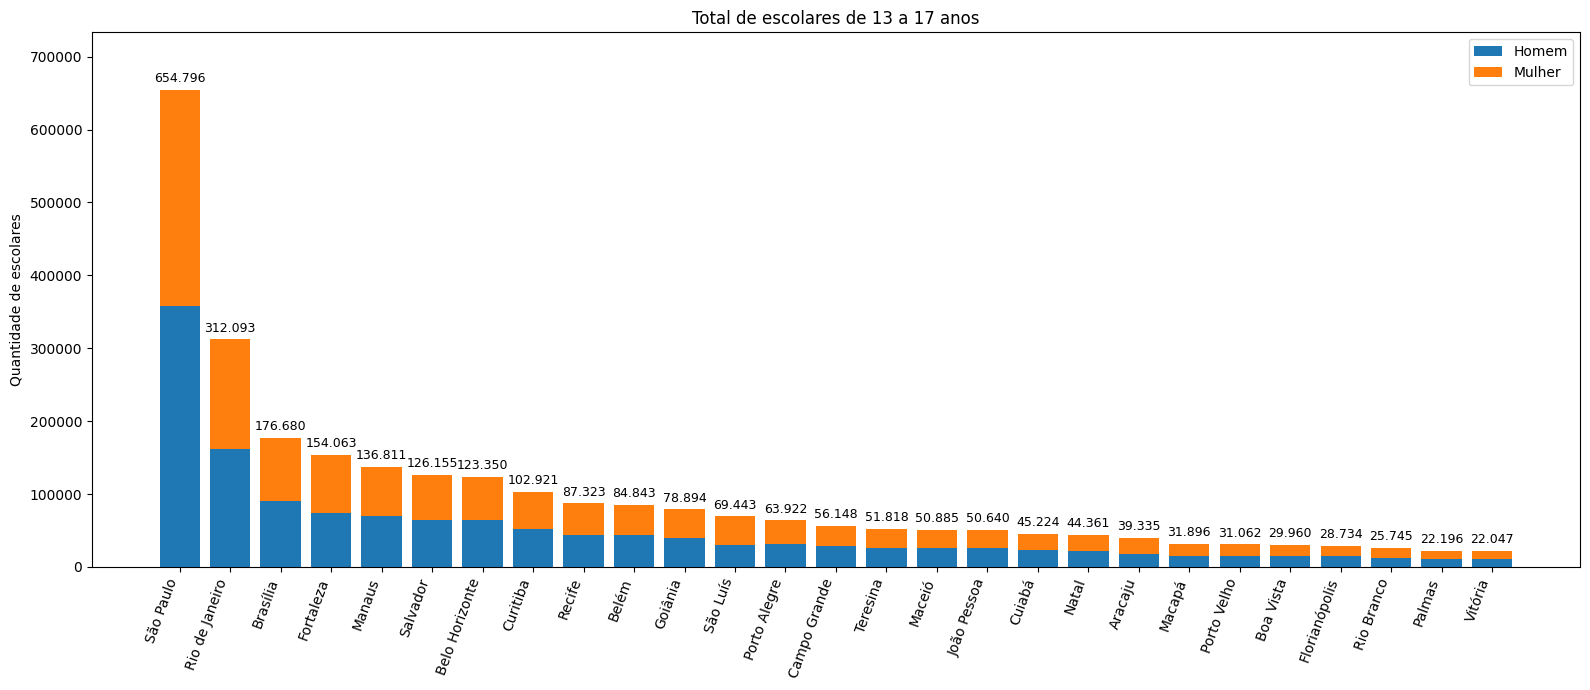

In [3]:
plot_data = data.sort_values("total_escolares", ascending=False).reset_index(drop=True)

plt.figure(figsize=(16, 7))

plt.bar(
    plot_data["indice"],
    plot_data["total_homem"],
    label="Homem",
)

plt.bar(
    plot_data["indice"],
    plot_data["total_mulher"],
    bottom=plot_data["total_homem"],
    label="Mulher",
)

offset = plot_data["total_escolares"].max() * 0.01
for i, total in enumerate(plot_data["total_escolares"]):
    plt.text(
        i,
        total + offset,
        f"{total:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.ylim(0, plot_data["total_escolares"].max() * 1.12)

plt.title("Total de escolares de 13 a 17 anos")
plt.ylabel("Quantidade de escolares")
plt.xticks(rotation=70, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
